## 🏥 Medical Data Visualizer

[![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-blue?logo=google-colab&style=flat-square)](https://colab.research.google.com/drive/1BNXvU_Oo1JyjWUWsbqBgWM_extGZxASv?usp=sharing)

### Overview

This notebook visualizes and analyzes medical examination data to explore the relationship between **cardiovascular disease** and various health metrics, blood markers, and lifestyle choices.

Medical data is crucial for understanding health trends and risk factors. By visualizing this data, we can identify patterns and correlations that may contribute to cardiovascular disease, ultimately aiding in prevention and treatment strategies.

### Data Source

The dataset is sourced from [Kaggle's Cardiovascular Disease dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset). It contains medical examination data for **70,000 patients**, including both objective measurements and subjective lifestyle factors.

### Dataset Description

The rows in the dataset represent patients and the columns represent information like body measurements, results from various blood tests, and lifestyle choices. We will use the dataset to explore the relationship between cardiac disease, body measurements, blood markers, and lifestyle choices.

| Feature                                       | Variable Type       | Variable    | Value Type                                       |
|-----------------------------------------------|---------------------|-------------|--------------------------------------------------|
| Age                                           | Objective Feature   | age         | int (days)                                       |
| Height                                        | Objective Feature   | height      | int (cm)                                         |
| Weight                                        | Objective Feature   | weight      | float (kg)                                       |
| Gender                                        | Objective Feature   | sex         | categorical code                                 |
| Systolic blood pressure                       | Examination Feature | ap_hi       | int                                              |
| Diastolic blood pressure                      | Examination Feature | ap_lo       | int                                              |
| Cholesterol                                   | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
| Glucose                                       | Examination Feature | gluc        | 1: normal, 2: above normal, 3: well above normal |
| Smoking                                       | Subjective Feature  | smoke       | binary                                           |
| Alcohol intake                                | Subjective Feature  | alco        | binary                                           |
| Physical activity                             | Subjective Feature  | active      | binary                                           |
| Presence or absence of cardiovascular disease | Target Variable     | cardio      | binary                                           |

### Tools & Techniques

- **pandas**: Data loading, aggregation, and statistical analysis
- **matplotlib**: Bar charts, histograms, pie charts, and multi-subplot layouts with annotations
- **seaborn**: Color palettes, categorical plots, and correlation heatmaps
- **numpy**: Numerical operations and upper-triangle mask generation
- **Feature Engineering**: BMI calculation → binary `overweight` column; `cholesterol`/`gluc` normalization (0 = good, 1 = bad)
- **Exploratory Data Analysis**: Distributions, patterns, and correlations across health metrics
- **Correlation Analysis**: Pearson correlation heatmap after filtering physiologically invalid records

### Key Research Questions

1. What is the overall cardiovascular disease rate, and how is the dataset balanced between diseased and healthy patients?
2. What proportion of patients are overweight (BMI > 25), and how does overweight status relate to cardiovascular disease?
3. How do abnormal cholesterol and glucose levels distribute across patients with and without cardiovascular disease?
4. Which categorical health features (`cholesterol`, `gluc`, `smoke`, `alco`, `active`, `overweight`) show the greatest imbalance between cardio=0 and cardio=1 groups?
5. Which features are most strongly correlated with cardiovascular disease, and are there significant inter-feature correlations?
6. How does cardiovascular disease prevalence vary across age groups?
7. What is the distribution of systolic blood pressure among patients with and without cardiovascular disease?
8. How do lifestyle factors (smoking, alcohol, physical activity) differ between diseased and healthy patient groups?

### Key Takeaways

This dataset is **artificially balanced (50% CVD / 50% no CVD) for machine learning purposes** and focuses on patients aged ~40–65. The 50% CVD rate does NOT reflect real-world prevalence (~20–35%) but rather dataset curation by the original researchers. The primary CVD predictors in this dataset are **age**, **systolic blood pressure**, and **cholesterol** (r ≈ +0.2 to +0.4), while lifestyle self-reports (`active`, `smoke`, `alco`) have near-zero correlation with disease (r ≈ 0.0). Consequently, it is normal for this dataset to show simultaneously high physical activity (80%), low smoking (9%), and 50% CVD prevalence — these statistics reflect the curated cohort composition, not population causality. This dataset is ideal for exploring clinical risk factor patterns and building predictive models, but not for estimating real-world CVD prevalence or assessing lifestyle intervention effectiveness.


In [26]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 📥 1. Data Loading & Overview

The dataset is loaded from a CSV file hosted on Google Drive. We first inspect the shape, columns, and a sample of the data to understand its structure.

> **Note:** `df` is the main dataset used throughout. Feature engineering occurs in Section 2. A copy `df_eda` with extra columns (`age_years`, `bmi`, `age_group`, `bmi_category`) is created in Section 3.3 for visualization — keeping `df` clean for `draw_cat_plot()` and `draw_heat_map()`.

In [27]:
# Load dataset from the provided CSV URL
df = pd.read_csv("https://drive.google.com/uc?id=1RFsl2Yy7r95yC3g9pG0In13wl4hi56Pg")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(df.head())

Dataset shape: 70,000 rows × 13 columns
Columns: ['id', 'age', 'sex', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
   id    age  sex  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393    2     168    62.0    110     80            1     1      0   
1   1  20228    1     156    85.0    140     90            3     1      0   
2   2  18857    1     165    64.0    130     70            3     1      0   
3   3  17623    2     169    82.0    150    100            1     1      0   
4   4  17474    1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [28]:
print("=== Data Types & Missing Values ===")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nCardiovascular disease distribution:")
print(df['cardio'].value_counts().rename({0: 'No Disease (0)', 1: 'Has Disease (1)'}))
print(f"\nDataset balance: {df['cardio'].mean() * 100:.1f}% have cardiovascular disease")

=== Data Types & Missing Values ===
id               int64
age              int64
sex              int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Missing values: 0

Cardiovascular disease distribution:
cardio
No Disease (0)     35021
Has Disease (1)    34979
Name: count, dtype: int64

Dataset balance: 50.0% have cardiovascular disease


In [29]:
df.describe()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349843,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.477253,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,3.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### 🔬 2. Feature Engineering

#### 2a. BMI & Overweight Column

$$\text{BMI} = \frac{\text{weight (kg)}}{(\text{height (m)})^2}$$

If BMI > 25 → `overweight = 1` (overweight), otherwise `overweight = 0` (not overweight).

> **Note:** The BMI value is first stored in `df['overweight']` as a float, then converted to binary `0`/`1`. This mirrors the step-by-step processing pipeline shown in the `.py` implementation.

In [30]:
# Adding overweight column — Step 1: compute raw BMI and store temporarily in 'overweight'
# NOTE: At this stage 'overweight' holds BMI float values (e.g. 26.4), NOT the final binary flag.
#       Binary conversion happens in the next cell.
df['overweight'] = df['weight'] / ((df['height'] / 100) ** 2)

print("Intermediate BMI values stored in 'overweight' column (binary conversion pending):")
print(df[['weight', 'height', 'overweight']].head().to_string())
print(f"\nBMI range at this stage: {df['overweight'].min():.1f} – {df['overweight'].max():.1f}")


Intermediate BMI values stored in 'overweight' column (binary conversion pending):
   weight  height  overweight
0    62.0     168   21.967120
1    85.0     156   34.927679
2    64.0     165   23.507805
3    82.0     169   28.710479
4    56.0     156   23.011177

BMI range at this stage: 3.5 – 298.7


In [31]:
# Converting BMI to binary — 1 if overweight (BMI > 25), 0 otherwise
df['overweight'] = df['overweight'].apply(lambda x: 1 if x > 25 else 0)
print(df.head())  # overweight column now shows binary 0/1

print(f"\nOverweight distribution:")
print(df['overweight'].value_counts().rename({0: 'Not overweight (0)', 1: 'Overweight (1)'}))
print(f"\nOverweight rate: {df['overweight'].mean() * 100:.1f}%")

   id    age  sex  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393    2     168    62.0    110     80            1     1      0   
1   1  20228    1     156    85.0    140     90            3     1      0   
2   2  18857    1     165    64.0    130     70            3     1      0   
3   3  17623    2     169    82.0    150    100            1     1      0   
4   4  17474    1     156    56.0    100     60            1     1      0   

   alco  active  cardio  overweight  
0     0       1       0           0  
1     0       1       1           1  
2     0       0       1           0  
3     0       1       1           1  
4     0       0       0           0  

Overweight distribution:
overweight
Overweight (1)        43546
Not overweight (0)    26454
Name: count, dtype: int64

Overweight rate: 62.2%


#### 2b. Normalize Cholesterol & Glucose

Normalize so that `0` = good (normal level) and `1` = bad (above normal):
- If original value `== 1` → set to `0` (normal)
- If original value `> 1` → set to `1` (above normal)

In [32]:
# Normalize: 0 = good (normal), 1 = bad (above normal)
df['cholesterol'] = df['cholesterol'].apply(lambda x: 1 if x > 1 else 0)
df['gluc']        = df['gluc'].apply(lambda x: 1 if x > 1 else 0)

# sort=False: preserves label order (0 before 1) instead of sorting by count
print("Normalized cholesterol distribution (0 = normal, 1 = above normal):")
print(df['cholesterol'].value_counts(sort=False))
print("\nNormalized glucose distribution (0 = normal, 1 = above normal):")
print(df['gluc'].value_counts(sort=False))
print(f"\ndf columns after feature engineering: {list(df.columns)}")


Normalized cholesterol distribution (0 = normal, 1 = above normal):
cholesterol
0    52385
1    17615
Name: count, dtype: int64

Normalized glucose distribution (0 = normal, 1 = above normal):
gluc
0    59479
1    10521
Name: count, dtype: int64

df columns after feature engineering: ['id', 'age', 'sex', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'overweight']


### 🔍 3. Exploratory Data Analysis (EDA)

Before implementing the required visualizations, we explore the dataset holistically — examining distributions, measuring correlations, and engineering additional variables to uncover patterns related to cardiovascular disease.

> **Note:** The `df` variable already contains the processed features (`overweight` as binary, normalized `cholesterol`/`gluc`). All EDA is performed on `df` directly or on a copy `df_eda` — the original `df` is never modified beyond what was done in Section 2.

#### 3.1 Distributions & Patterns

Understanding the shape and spread of key variables helps identify trends, detect anomalies, and form hypotheses about the relationships between health metrics and cardiovascular disease.

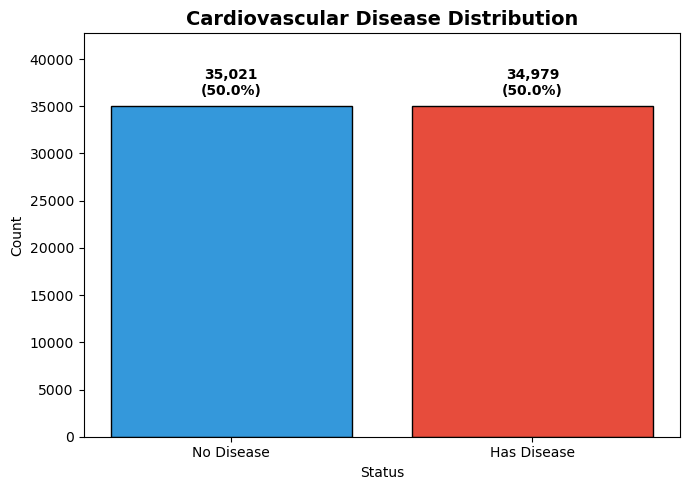

In [33]:
# Cardiovascular disease distribution (Q1)
# sort_index() ensures 0 (No Disease) always comes before 1 (Has Disease)
# so bar colors are always correctly assigned positionally
cardio_counts = df['cardio'].value_counts().sort_index().rename({0: 'No Disease', 1: 'Has Disease'})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(cardio_counts.index, cardio_counts.values,
              color=['#3498db', '#e74c3c'], edgecolor='black')  # blue=No Disease, red=Has Disease
ax.set_title('Cardiovascular Disease Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_ylim(0, max(cardio_counts.values) * 1.22)
for bar, (_, v) in zip(bars, cardio_counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(cardio_counts.values) * 0.025,
            f'{v:,}\n({v / len(df) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


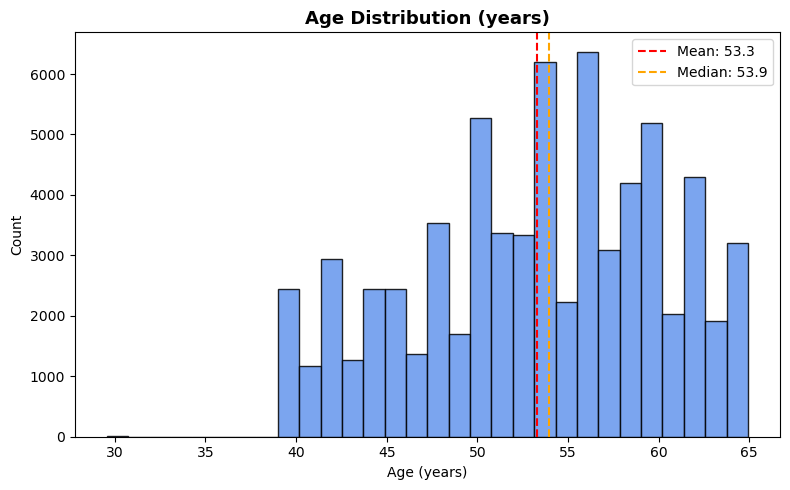

In [34]:
# Age distribution
age_years = (df['age'] / 365.25)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(age_years, bins=30, color='cornflowerblue', edgecolor='black', alpha=0.85)
ax.axvline(age_years.mean(),   color='red',    linestyle='--', linewidth=1.5,
           label=f"Mean: {age_years.mean():.1f}")
ax.axvline(age_years.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f"Median: {age_years.median():.1f}")
ax.set_title('Age Distribution (years)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

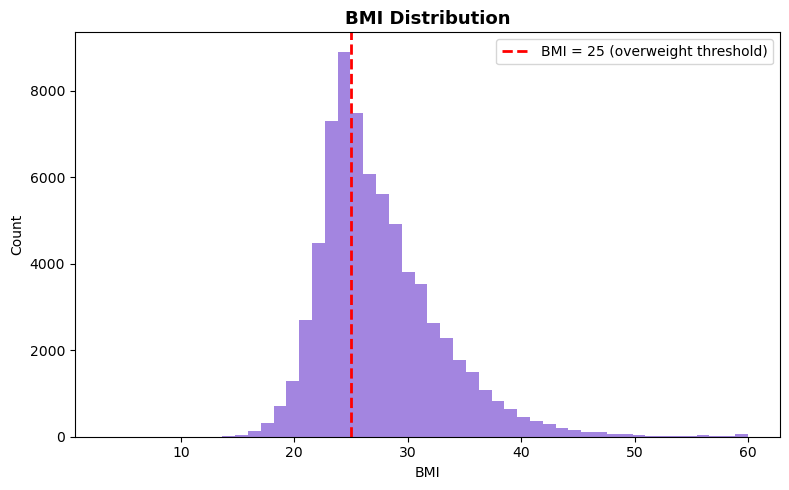

In [35]:
# BMI distribution
bmi_vals = df['weight'] / ((df['height'] / 100) ** 2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bmi_vals.clip(upper=60), bins=50, color='mediumpurple', edgecolor='none', alpha=0.85)
ax.axvline(25, color='red', linestyle='--', linewidth=2, label='BMI = 25 (overweight threshold)')
ax.set_title('BMI Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

Rows removed by SBP filter: 247 (0.35%)
Rows remaining: 69,753


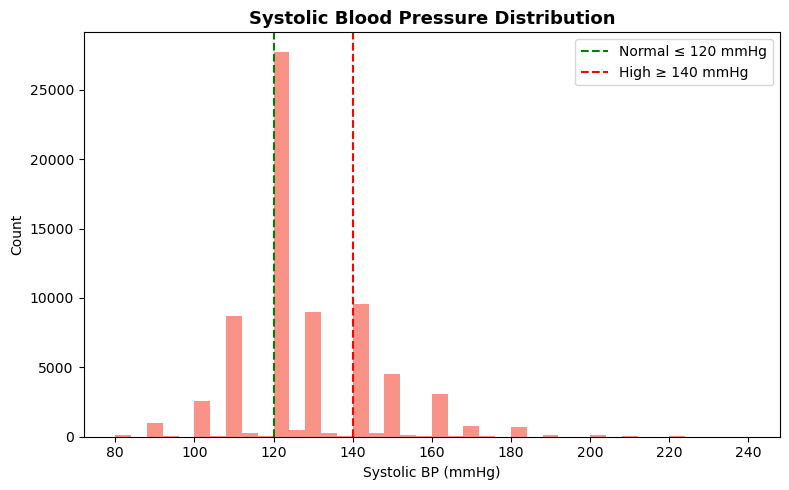

In [36]:
# Systolic blood pressure distribution
# Filter bounds: 80–250 mmHg removes physiologically impossible values.
#   < 80 mmHg systolic suggests cardiogenic shock or severe data entry error.
#   > 250 mmHg systolic is an extreme hypertensive crisis, almost certainly a data error.
n_before = len(df)
df_bp = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
n_filtered = n_before - len(df_bp)
print(f"Rows removed by SBP filter: {n_filtered:,} ({n_filtered / n_before * 100:.2f}%)")
print(f"Rows remaining: {len(df_bp):,}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_bp['ap_hi'], bins=40, color='salmon', edgecolor='none', alpha=0.85)
ax.axvline(120, color='green', linestyle='--', linewidth=1.5, label='Normal ≤ 120 mmHg')
ax.axvline(140, color='red',   linestyle='--', linewidth=1.5, label='High ≥ 140 mmHg')
ax.set_title('Systolic Blood Pressure Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Systolic BP (mmHg)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


#### 3.2 Correlation Analysis

Quantifying linear relationships between numeric features and the cardiovascular disease indicator helps identify which factors are most strongly associated with disease presence, guiding interpretation and informing potential predictive modeling.

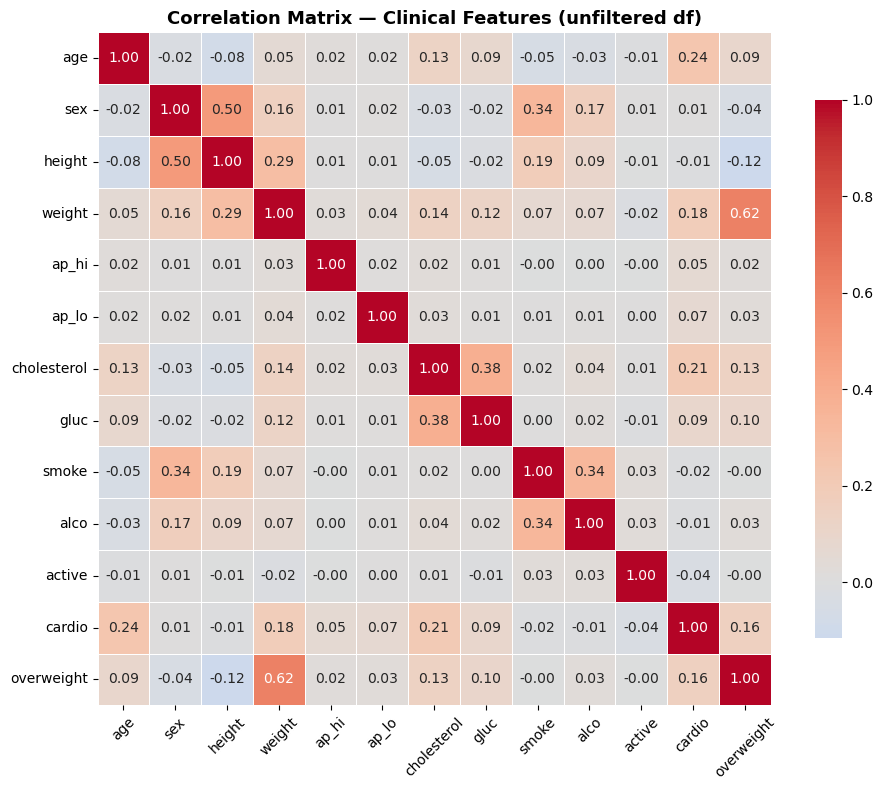

In [37]:
# Full Pearson correlation heatmap — all clinical features (id excluded: it is a patient identifier,
# not a clinical variable, so correlating it with health outcomes would be meaningless noise)
# numeric_only=True — explicit and safe for pandas 2.0+
# NOTE: this heatmap uses the full unfiltered df (all 70,000 rows).
#       Section 5 draw_heat_map() uses a cleaned subset — values will differ slightly.
corr_matrix = df.drop(columns=['id']).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Clinical Features (unfiltered df)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


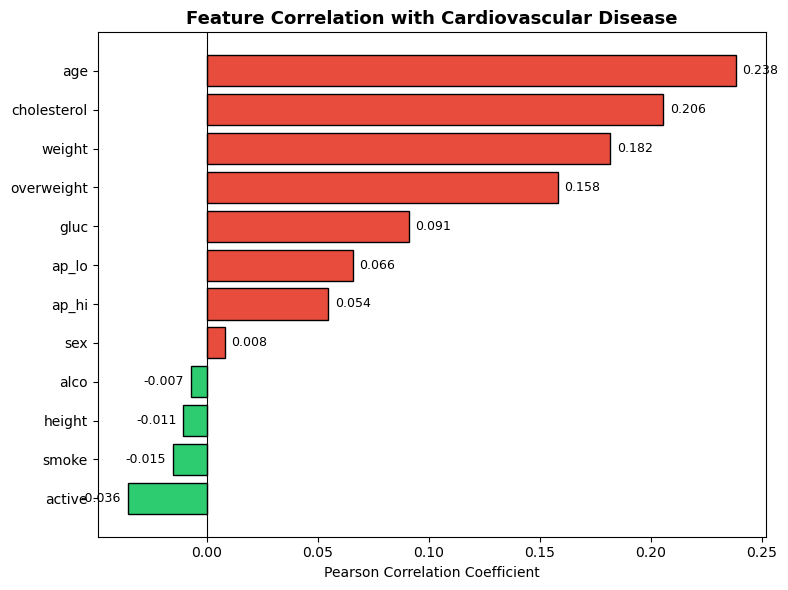

In [38]:
# Feature correlation with cardiovascular disease — ranked horizontal bar chart (Q5)
# Color convention:
#   RED  (#e74c3c) = positive correlation → risk factors (more of this = more disease)
#   GREEN (#2ecc71) = negative correlation → protective factors (more of this = less disease)
cardio_corr = corr_matrix['cardio'].drop('cardio').sort_values()
bar_colors  = ['#2ecc71' if v < 0 else '#e74c3c' for v in cardio_corr.values]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(cardio_corr.index, cardio_corr.values, color=bar_colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Cardiovascular Disease', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
for i, v in enumerate(cardio_corr.values):
    offset = 0.003 if v >= 0 else -0.003
    ax.text(v + offset, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


In [39]:
# Key insights summary (Q5)
print("\nKey features correlated with cardiovascular disease:")
top_pos = cardio_corr[cardio_corr > 0].sort_values(ascending=False)
top_neg = cardio_corr[cardio_corr < 0].sort_values()
for col, val in top_pos.items():
    print(f"  ↑ {col:<15} r = {val:.3f}  (positively associated with disease)")
for col, val in top_neg.items():
    print(f"  ↓ {col:<15} r = {val:.3f}  (negatively associated with disease)")


Key features correlated with cardiovascular disease:
  ↑ age             r = 0.238  (positively associated with disease)
  ↑ cholesterol     r = 0.206  (positively associated with disease)
  ↑ weight          r = 0.182  (positively associated with disease)
  ↑ overweight      r = 0.158  (positively associated with disease)
  ↑ gluc            r = 0.091  (positively associated with disease)
  ↑ ap_lo           r = 0.066  (positively associated with disease)
  ↑ ap_hi           r = 0.054  (positively associated with disease)
  ↑ sex             r = 0.008  (positively associated with disease)
  ↓ active          r = -0.036  (negatively associated with disease)
  ↓ smoke           r = -0.015  (negatively associated with disease)
  ↓ height          r = -0.011  (negatively associated with disease)
  ↓ alco            r = -0.007  (negatively associated with disease)


#### 3.3 Feature Engineering for EDA

Deriving additional variables (`age_years`, `bmi`, `age_group`, `bmi_category`) enables richer analysis of cardiovascular risk patterns.

In [40]:
# Create df_eda — a copy with derived columns for richer EDA visualizations
df_eda = df.copy()
df_eda['age_years']    = (df_eda['age'] / 365.25).round(1)
df_eda['bmi']          = df_eda['weight'] / ((df_eda['height'] / 100) ** 2)
df_eda['age_group']    = pd.cut(df_eda['age_years'],
                                 bins=[0, 30, 40, 50, 60, 120],
                                 labels=['≤30', '31–40', '41–50', '51–60', '60+'])
df_eda['bmi_category'] = pd.cut(df_eda['bmi'],
                                 bins=[0, 18.5, 25, 30, 200],
                                 labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

print("Engineered features added to df_eda:")
print(f"  age_years    : mean = {df_eda['age_years'].mean():.1f} yrs")
print(f"  bmi          : mean = {df_eda['bmi'].mean():.1f} | median = {df_eda['bmi'].median():.1f}")
print(f"  age_group    : {list(df_eda['age_group'].cat.categories)}")
print(f"  bmi_category : {list(df_eda['bmi_category'].cat.categories)}")

Engineered features added to df_eda:
  age_years    : mean = 53.3 yrs
  bmi          : mean = 27.6 | median = 26.4
  age_group    : ['≤30', '31–40', '41–50', '51–60', '60+']
  bmi_category : ['Underweight', 'Normal', 'Overweight', 'Obese']


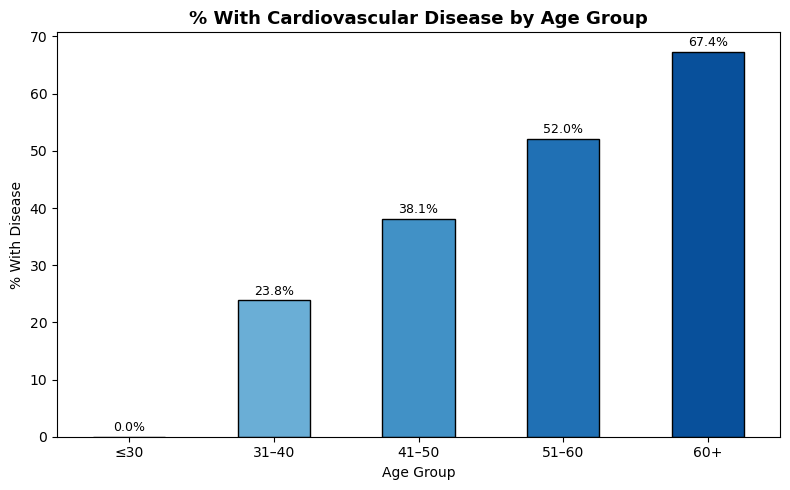

In [41]:
# % with cardiovascular disease by age group (Q6)
# 'Blues' palette (light → dark): ≤30 gets the lightest blue (low CVD rate),
# 60+ gets the darkest blue (highest CVD rate) — darker color = more disease (intuitive)
age_cardio = df_eda.groupby('age_group', observed=True)['cardio'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
age_cardio.plot(kind='bar', ax=ax,
                color=sns.color_palette('Blues', len(age_cardio) + 2)[2:], edgecolor='black')
ax.set_title('% With Cardiovascular Disease by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('% With Disease')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(age_cardio):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


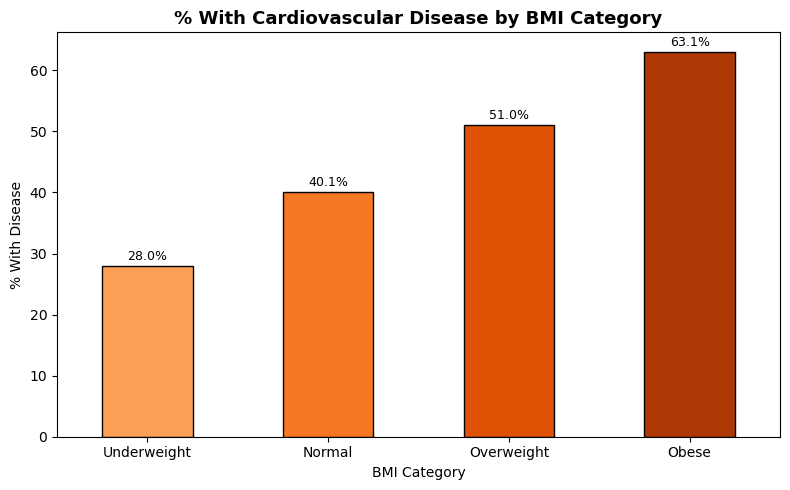

In [42]:
# % with cardiovascular disease by BMI category (Q2)
# 'Oranges' palette (light → dark): Underweight gets the lightest orange,
# Obese gets the darkest orange — darker color = more disease (intuitive)
bmi_cardio = df_eda.groupby('bmi_category', observed=True)['cardio'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bmi_cardio.plot(kind='bar', ax=ax,
                color=sns.color_palette('Oranges', len(bmi_cardio) + 2)[2:], edgecolor='black')
ax.set_title('% With Cardiovascular Disease by BMI Category', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI Category')
ax.set_ylabel('% With Disease')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(bmi_cardio):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


### 📊 4. Categorical Plot

Comparing value counts of categorical health features (`cholesterol`, `gluc`, `smoke`, `alco`, `active`, `overweight`) between patients **with** and **without** cardiovascular disease.

> The `draw_cat_plot()` function uses the global `df` (no arguments required). The x-axis label is `variable`, the y-axis label is `total`, and the plot is split into two panels by `cardio` status.

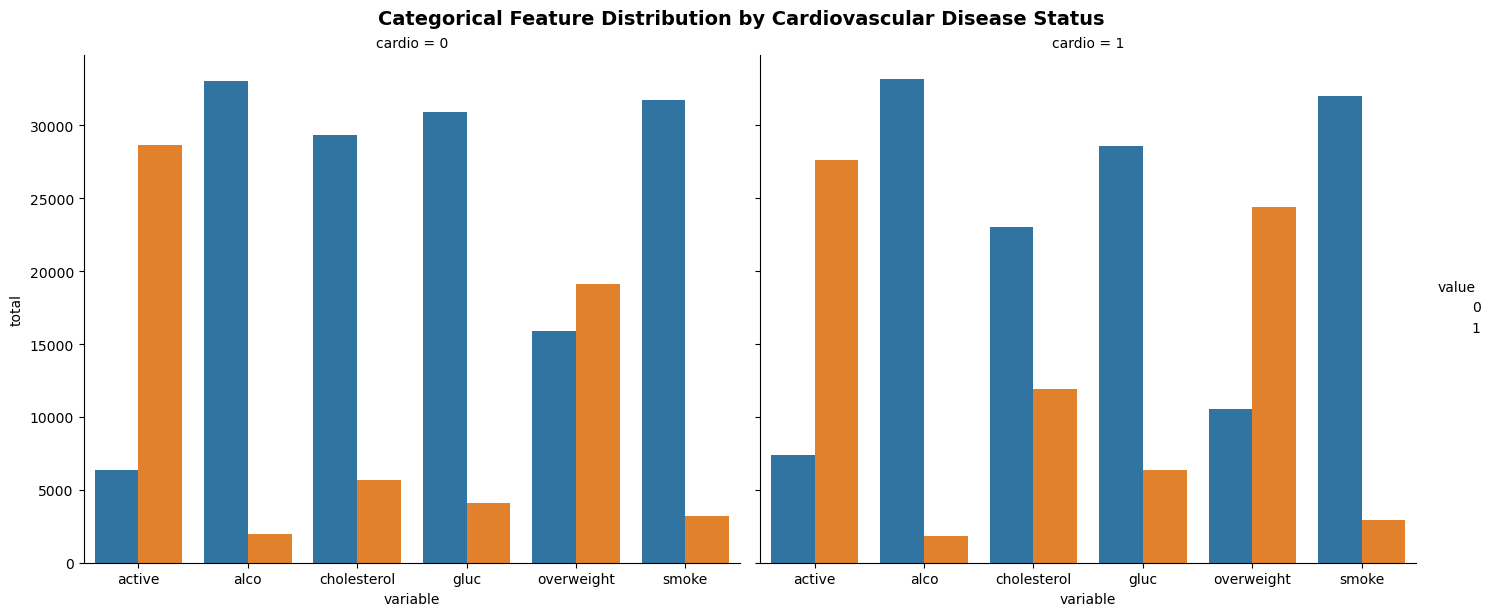

In [43]:
def draw_cat_plot():
    """Draw a categorical bar plot split by cardiovascular disease status.

    Uses the global df. Returns a matplotlib Figure.
    Axis labels: x = 'variable', y = 'total' (required by unit tests).
    """
    # dataframe for cat plot using pd.melt
    df_cat = pd.melt(
        df,
        id_vars=['cardio'],
        value_vars=['active', 'alco', 'cholesterol', 'gluc', 'overweight', 'smoke']
    )

    df_cat['total'] = 1  # add total column for counting
    df_cat = df_cat.groupby(['cardio', 'variable', 'value'], as_index=False).count()

    cat_grid = sns.catplot(
        x='variable', y='total',
        hue='value', col='cardio',
        data=df_cat, kind='bar',
        col_order=[0, 1],      # cardio=0 (No Disease) left, cardio=1 (Has Disease) right
        hue_order=[0, 1],      # 0 (good/normal) always first hue, 1 (bad/abnormal) always second
        height=6, aspect=1.2
    )

    cat_grid.figure.suptitle(
        'Categorical Feature Distribution by Cardiovascular Disease Status',
        fontsize=14, fontweight='bold', y=1.02
    )

    fig = cat_grid.figure

    return fig


cat_fig = draw_cat_plot()
plt.show()


### 🔥 5. Correlation Heat Map

Visualizing the Pearson correlation between all numerical features after cleaning physiologically invalid records:
- Rows where diastolic pressure > systolic pressure (`ap_lo > ap_hi`)
- Height values below the 2.5th or above the 97.5th percentile
- Weight values below the 2.5th or above the 97.5th percentile

> The `draw_heat_map()` function uses the global `df` (no arguments required). The heatmap shows only the lower triangle and uses `fmt='.1f'` annotations.


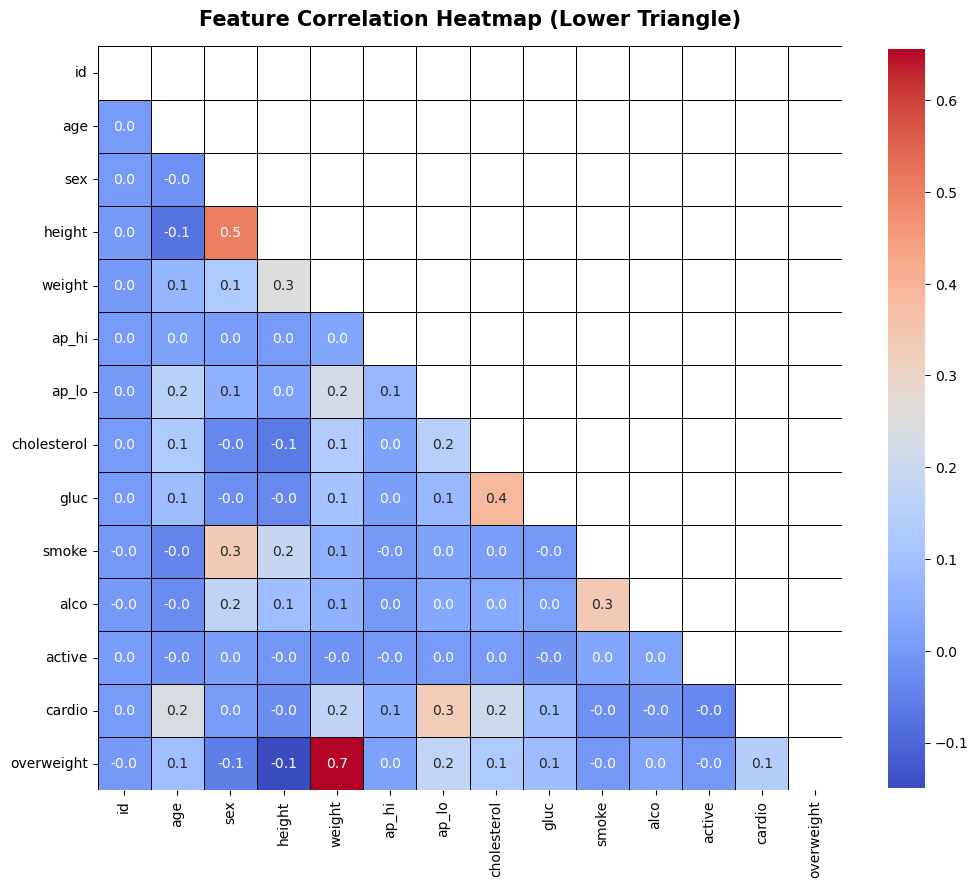

In [44]:
def draw_heat_map():
    """Draw a correlation heatmap after cleaning outlier/invalid data.

    Uses the global df. Returns a matplotlib Figure.
    Heatmap columns: id, age, sex, height, weight, ap_hi, ap_lo,
                     cholesterol, gluc, smoke, alco, active, cardio, overweight.
    """

    df_heat = df[
        (df['ap_lo']  <= df['ap_hi'])                          # diastolic ≤ systolic
        & (df['height'] >= df['height'].quantile(0.025))       # remove height outliers (low)
        & (df['height'] <= df['height'].quantile(0.975))       # remove height outliers (high)
        & (df['weight'] >= df['weight'].quantile(0.025))       # remove weight outliers (low)
        & (df['weight'] <= df['weight'].quantile(0.975))       # remove weight outliers (high)
    ]

    corr = df_heat.corr(numeric_only=True)                    # numeric_only=True: safe for pandas 2.0+
    mask = np.triu(np.ones_like(corr, dtype=bool))            # mask for the upper triangle
    fig, ax = plt.subplots(figsize=(12, 12))

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.1f',
        cmap='coolwarm',
        cbar_kws={'shrink': 0.8},
        square=True,
        linewidths=0.5,
        linecolor='black',
        ax=ax
    )

    ax.set_title('Feature Correlation Heatmap (Lower Triangle)',
                 fontsize=15, fontweight='bold', pad=15)

    return fig


heat_fig = draw_heat_map()
plt.show()


### 📈 6. Additional Insights

Deeper exploration of the dataset: age distribution by cardiovascular status, systolic blood pressure patterns, and lifestyle/biomarker factor comparisons across disease groups.

> Uses `df_eda` (the enriched copy created in Section 3) — `df` is not modified.

#### 6.1 Age Distribution by Cardiovascular Status

Overlay histogram comparing the **age distribution** of patients with and without cardiovascular disease.

- Patients **with disease** tend to be older, reflecting age as a primary risk factor.

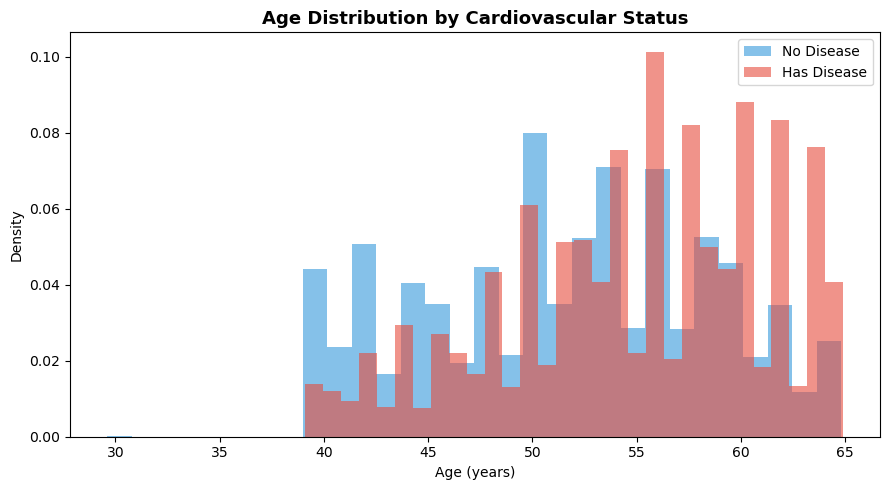

In [45]:
# Age distribution by cardiovascular status (Q6)
fig, ax = plt.subplots(figsize=(9, 5))
for label, group in df_eda.groupby('cardio'):
    ax.hist(group['age_years'], bins=30, alpha=0.6,
            label='Has Disease' if label == 1 else 'No Disease',
            color='#e74c3c' if label == 1 else '#3498db',
            edgecolor='none', density=True)
ax.set_title('Age Distribution by Cardiovascular Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.2 Systolic Blood Pressure Distribution by Cardiovascular Status

Overlay histogram comparing the **systolic blood pressure distribution** across disease groups.

- Patients with cardiovascular disease tend to have higher systolic blood pressure.

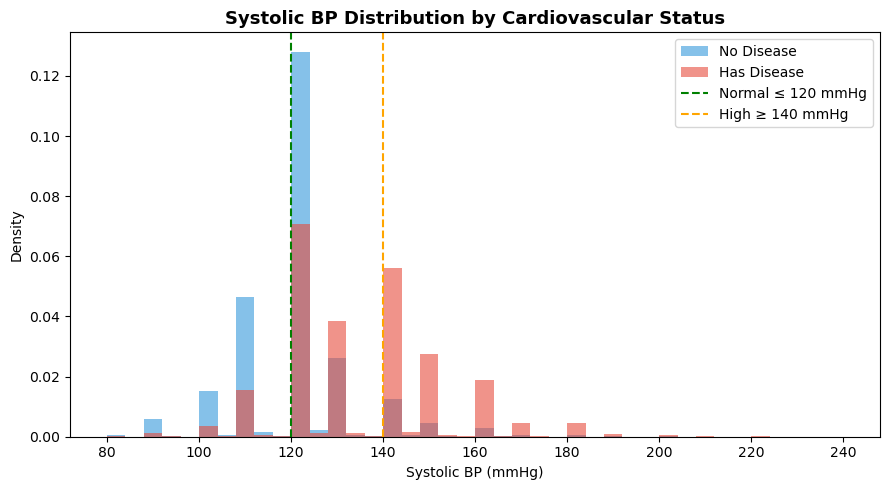

In [46]:
# Systolic blood pressure distribution by cardiovascular status (Q7)
# Same SBP filter as section 3.1 (80–250 mmHg) to remove physiologically impossible values
df_bp = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]

fig, ax = plt.subplots(figsize=(9, 5))
for label, group in df_bp.groupby('cardio'):
    ax.hist(group['ap_hi'], bins=40, alpha=0.6, density=True,
            label='Has Disease' if label == 1 else 'No Disease',
            color='#e74c3c' if label == 1 else '#3498db',
            edgecolor='none')
ax.axvline(120, color='green', linestyle='--', linewidth=1.5, label='Normal ≤ 120 mmHg')
ax.axvline(140, color='orange', linestyle='--', linewidth=1.5, label='High ≥ 140 mmHg')
ax.set_title('Systolic BP Distribution by Cardiovascular Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Systolic BP (mmHg)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


#### 6.3 Lifestyle Factors by Cardiovascular Status

Grouped bar chart showing the proportion of patients who **smoke, consume alcohol, or are physically active** across disease groups.

- Physical activity rates are **nearly identical** between both groups (~80%), confirming the near-zero correlation (r ≈ -0.0) seen in Section 3.2. Lifestyle self-reports have virtually no predictive power for CVD in this dataset.
- Smoking and alcohol consumption are also similarly low in both groups, reinforcing that the primary CVD predictors here are **age, blood pressure, and cholesterol** — not self-reported lifestyle habits.


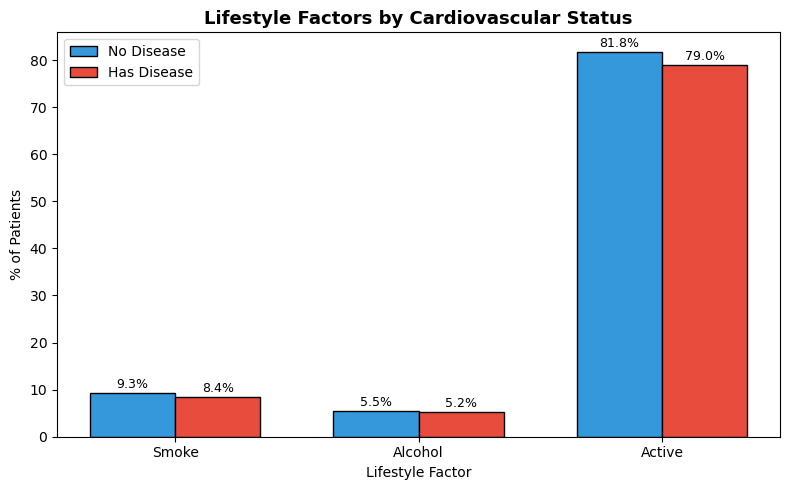

In [47]:
# Lifestyle factors by cardiovascular status (Q8)
lifestyle = ['smoke', 'alco', 'active']
labels    = ['Smoke', 'Alcohol', 'Active']

data_no  = [df[df['cardio'] == 0][col].mean() * 100 for col in lifestyle]
data_yes = [df[df['cardio'] == 1][col].mean() * 100 for col in lifestyle]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, data_no,  width, label='No Disease', color='#3498db', edgecolor='black')
ax.bar(x + width / 2, data_yes, width, label='Has Disease', color='#e74c3c', edgecolor='black')
ax.set_title('Lifestyle Factors by Cardiovascular Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Lifestyle Factor')
ax.set_ylabel('% of Patients')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for xi, (n, y) in zip(x, zip(data_no, data_yes)):
    ax.text(xi - width / 2, n + 0.4, f'{n:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.text(xi + width / 2, y + 0.4, f'{y:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Biomarker Levels by Cardiovascular Status

Grouped bar chart showing the proportion of patients with **elevated cholesterol, elevated glucose, and overweight** across disease groups.

- Elevated cholesterol and glucose are strongly associated with cardiovascular disease presence.

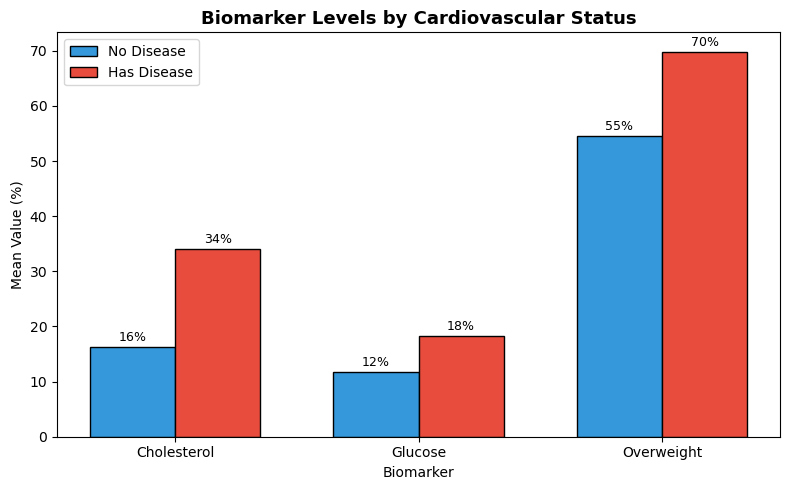

In [48]:
# Biomarker levels by cardiovascular status (Q2/Q3)
biomarkers = ['cholesterol', 'gluc', 'overweight']
labels = ['Cholesterol', 'Glucose', 'Overweight']

data_no  = [df[df['cardio'] == 0][col].mean() * 100 for col in biomarkers]
data_yes = [df[df['cardio'] == 1][col].mean() * 100 for col in biomarkers]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, data_no,  width, label='No Disease', color='#3498db', edgecolor='black')
ax.bar(x + width / 2, data_yes, width, label='Has Disease', color='#e74c3c', edgecolor='black')
ax.set_title('Biomarker Levels by Cardiovascular Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Biomarker')
ax.set_ylabel('Mean Value (%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for xi, (n, y) in zip(x, zip(data_no, data_yes)):
    ax.text(xi - width / 2, n + 0.5, f'{n:.0f}%', ha='center', va='bottom', fontsize=9)
    ax.text(xi + width / 2, y + 0.5, f'{y:.0f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 📊 7. Summary

Compiling key statistics from the medical data analysis into a structured output.

> **Interpretation reminder:** The 50% CVD rate reflects an artificially balanced ML dataset, not real-world prevalence. High physical activity (80%) alongside 50% CVD and 62% overweight is expected given the near-zero correlation between lifestyle self-reports and CVD (r ≈ 0.0). The real drivers are age, systolic blood pressure, and cholesterol.


In [49]:
cardio_rate     = df['cardio'].mean() * 100
overweight_rate = df['overweight'].mean() * 100
chol_abnormal   = df['cholesterol'].mean() * 100
gluc_abnormal   = df['gluc'].mean() * 100
smokers         = df['smoke'].mean() * 100
drinkers        = df['alco'].mean() * 100
physically_act  = df['active'].mean() * 100
avg_age         = (df['age'] / 365.25).mean()

print("=" * 52)
print("       MEDICAL DATA ANALYSIS — SUMMARY")
print("=" * 52)
print(f"  Total patients                  : {len(df):,}")
print(f"  Average age                     : {avg_age:.1f} years")
print(f"  Cardiovascular disease rate     : {cardio_rate:.1f}%")
print(f"  Overweight (BMI > 25)           : {overweight_rate:.1f}%")
print(f"  Abnormal cholesterol            : {chol_abnormal:.1f}%")
print(f"  Abnormal glucose                : {gluc_abnormal:.1f}%")
print(f"  Smokers                         : {smokers:.1f}%")
print(f"  Alcohol consumers               : {drinkers:.1f}%")
print(f"  Physically active               : {physically_act:.1f}%")
print("=" * 52)

       MEDICAL DATA ANALYSIS — SUMMARY
  Total patients                  : 70,000
  Average age                     : 53.3 years
  Cardiovascular disease rate     : 50.0%
  Overweight (BMI > 25)           : 62.2%
  Abnormal cholesterol            : 25.2%
  Abnormal glucose                : 15.0%
  Smokers                         : 8.8%
  Alcohol consumers               : 5.4%
  Physically active               : 80.4%
